In [123]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [124]:
df =pd.read_csv("laptop_price.csv" ,encoding = "latin")

In [125]:
df

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1298,1316,Lenovo,Yoga 500-14ISK,2 in 1 Convertible,14.0,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 6500U 2.5GHz,4GB,128GB SSD,Intel HD Graphics 520,Windows 10,1.8kg,638.00
1299,1317,Lenovo,Yoga 900-13ISK,2 in 1 Convertible,13.3,IPS Panel Quad HD+ / Touchscreen 3200x1800,Intel Core i7 6500U 2.5GHz,16GB,512GB SSD,Intel HD Graphics 520,Windows 10,1.3kg,1499.00
1300,1318,Lenovo,IdeaPad 100S-14IBR,Notebook,14.0,1366x768,Intel Celeron Dual Core N3050 1.6GHz,2GB,64GB Flash Storage,Intel HD Graphics,Windows 10,1.5kg,229.00
1301,1319,HP,15-AC110nv (i7-6500U/6GB/1TB/Radeon,Notebook,15.6,1366x768,Intel Core i7 6500U 2.5GHz,6GB,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19kg,764.00


In [126]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   laptop_ID         1303 non-null   int64  
 1   Company           1303 non-null   str    
 2   Product           1303 non-null   str    
 3   TypeName          1303 non-null   str    
 4   Inches            1303 non-null   float64
 5   ScreenResolution  1303 non-null   str    
 6   Cpu               1303 non-null   str    
 7   Ram               1303 non-null   str    
 8   Memory            1303 non-null   str    
 9   Gpu               1303 non-null   str    
 10  OpSys             1303 non-null   str    
 11  Weight            1303 non-null   str    
 12  Price_euros       1303 non-null   float64
dtypes: float64(2), int64(1), str(10)
memory usage: 132.5 KB


In [127]:
df.describe()

,laptop_ID,Inches,Price_euros
count,1303.000000,1303.000000,1303.000000
mean,660.155794,15.017191,1123.686992
std,381.172104,1.426304,699.009043
min,1.000000,10.100000,174.000000
25%,331.500000,14.000000,599.000000
50%,659.000000,15.600000,977.000000
75%,990.500000,15.600000,1487.880000
max,1320.000000,18.400000,6099.000000


In [128]:
df.shape

(1303, 13)

In [129]:
# Ram replace GB
df["Ram"] = df["Ram"].apply((lambda a :a.replace("GB" , "")))


In [130]:
df["Ram"] = df["Ram"].apply((lambda a : int(a)))

In [131]:
df['Ram']

0        8
1        8
2        8
3       16
4        8
        ..
1298     4
1299    16
1300     2
1301     6
1302     4
Name: Ram, Length: 1303, dtype: int64

In [132]:
df["Price"] = df["Price_euros"].apply((lambda a : int(a)))

In [133]:
df["Price"]

0       1339
1        898
2        575
3       2537
4       1803
        ... 
1298     638
1299    1499
1300     229
1301     764
1302     369
Name: Price, Length: 1303, dtype: int64

In [134]:
df.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros,Price
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69,1339
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94,898
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00,575
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45,2537
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60,1803


In [135]:
df = df.drop('Price_euros', axis = 1)

In [136]:
df['Price'] = df['Price'] * 110.6

In [137]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   laptop_ID         1303 non-null   int64  
 1   Company           1303 non-null   str    
 2   Product           1303 non-null   str    
 3   TypeName          1303 non-null   str    
 4   Inches            1303 non-null   float64
 5   ScreenResolution  1303 non-null   str    
 6   Cpu               1303 non-null   str    
 7   Ram               1303 non-null   int64  
 8   Memory            1303 non-null   str    
 9   Gpu               1303 non-null   str    
 10  OpSys             1303 non-null   str    
 11  Weight            1303 non-null   str    
 12  Price             1303 non-null   float64
dtypes: float64(2), int64(2), str(9)
memory usage: 132.5 KB


In [138]:
df = df.drop('laptop_ID', axis = 1)

In [139]:
df = df.drop('Product', axis = 1)

In [140]:
df

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,148093.4
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,99318.8
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,63595.0
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,280592.2
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,199411.8
...,...,...,...,...,...,...,...,...,...,...,...
1298,Lenovo,2 in 1 Convertible,14.0,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 6500U 2.5GHz,4,128GB SSD,Intel HD Graphics 520,Windows 10,1.8kg,70562.8
1299,Lenovo,2 in 1 Convertible,13.3,IPS Panel Quad HD+ / Touchscreen 3200x1800,Intel Core i7 6500U 2.5GHz,16,512GB SSD,Intel HD Graphics 520,Windows 10,1.3kg,165789.4
1300,Lenovo,Notebook,14.0,1366x768,Intel Celeron Dual Core N3050 1.6GHz,2,64GB Flash Storage,Intel HD Graphics,Windows 10,1.5kg,25327.4
1301,HP,Notebook,15.6,1366x768,Intel Core i7 6500U 2.5GHz,6,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19kg,84498.4


In [141]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1303 non-null   str    
 1   TypeName          1303 non-null   str    
 2   Inches            1303 non-null   float64
 3   ScreenResolution  1303 non-null   str    
 4   Cpu               1303 non-null   str    
 5   Ram               1303 non-null   int64  
 6   Memory            1303 non-null   str    
 7   Gpu               1303 non-null   str    
 8   OpSys             1303 non-null   str    
 9   Weight            1303 non-null   str    
 10  Price             1303 non-null   float64
dtypes: float64(2), int64(1), str(8)
memory usage: 112.1 KB


In [142]:
df.groupby("Company")['Company'].value_counts() > 10

Company
Acer          True
Apple         True
Asus          True
Chuwi        False
Dell          True
Fujitsu      False
Google       False
HP            True
Huawei       False
LG           False
Lenovo        True
MSI           True
Mediacom     False
Microsoft    False
Razer        False
Samsung      False
Toshiba       True
Vero         False
Xiaomi       False
Name: count, dtype: bool

<Axes: xlabel='TypeName', ylabel='Inches'>

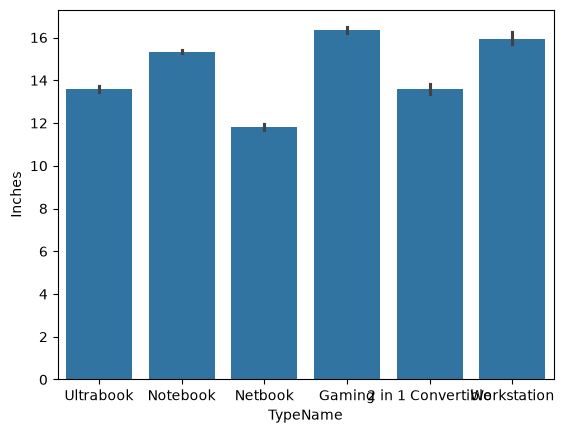

In [143]:
sns.barplot(x = df["TypeName"] , y = df["Inches"])

In [144]:
# df['TypeName'].value_counts().plot(kind=)

In [145]:
  # Step 8: Feature Extraction from 'ScreenResolution' — X_Res and Y_Res

df['ScreenResolution']

0               IPS Panel Retina Display 2560x1600
1                                         1440x900
2                                Full HD 1920x1080
3               IPS Panel Retina Display 2880x1800
4               IPS Panel Retina Display 2560x1600
                           ...                    
1298     IPS Panel Full HD / Touchscreen 1920x1080
1299    IPS Panel Quad HD+ / Touchscreen 3200x1800
1300                                      1366x768
1301                                      1366x768
1302                                      1366x768
Name: ScreenResolution, Length: 1303, dtype: str

In [146]:
a = 'IPS Panel Retina Display 2560x1600'

In [147]:
a

'IPS Panel Retina Display 2560x1600'

In [148]:
a.split()[-1].split('x')[0]

'2560'

In [149]:
df['X_Res'] = df['ScreenResolution'].apply(lambda x: int(x.split()[-1].split('x')[0]))


In [150]:
df

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,X_Res
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,148093.4,2560
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,99318.8,1440
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,63595.0,1920
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,280592.2,2880
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,199411.8,2560
...,...,...,...,...,...,...,...,...,...,...,...,...
1298,Lenovo,2 in 1 Convertible,14.0,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 6500U 2.5GHz,4,128GB SSD,Intel HD Graphics 520,Windows 10,1.8kg,70562.8,1920
1299,Lenovo,2 in 1 Convertible,13.3,IPS Panel Quad HD+ / Touchscreen 3200x1800,Intel Core i7 6500U 2.5GHz,16,512GB SSD,Intel HD Graphics 520,Windows 10,1.3kg,165789.4,3200
1300,Lenovo,Notebook,14.0,1366x768,Intel Celeron Dual Core N3050 1.6GHz,2,64GB Flash Storage,Intel HD Graphics,Windows 10,1.5kg,25327.4,1366
1301,HP,Notebook,15.6,1366x768,Intel Core i7 6500U 2.5GHz,6,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19kg,84498.4,1366


In [151]:
a.split()[-1].split('x')[1]

'1600'

In [152]:
df['Y_Res'] = df['ScreenResolution'].apply(lambda x: int(x.split()[-1].split('x')[1]))

In [153]:
df

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,X_Res,Y_Res
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,148093.4,2560,1600
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,99318.8,1440,900
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,63595.0,1920,1080
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,280592.2,2880,1800
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,199411.8,2560,1600
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1298,Lenovo,2 in 1 Convertible,14.0,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 6500U 2.5GHz,4,128GB SSD,Intel HD Graphics 520,Windows 10,1.8kg,70562.8,1920,1080
1299,Lenovo,2 in 1 Convertible,13.3,IPS Panel Quad HD+ / Touchscreen 3200x1800,Intel Core i7 6500U 2.5GHz,16,512GB SSD,Intel HD Graphics 520,Windows 10,1.3kg,165789.4,3200,1800
1300,Lenovo,Notebook,14.0,1366x768,Intel Celeron Dual Core N3050 1.6GHz,2,64GB Flash Storage,Intel HD Graphics,Windows 10,1.5kg,25327.4,1366,768
1301,HP,Notebook,15.6,1366x768,Intel Core i7 6500U 2.5GHz,6,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19kg,84498.4,1366,768


In [154]:
a = 'IPS Panel Retina Display 2880x1800'

In [155]:
a

'IPS Panel Retina Display 2880x1800'

In [156]:
# df['Touchscreen'] = df['ScreenResolution'].apply(lambda x: 1 if 'Touchscreen' in x else 0)
# df['IPS'] = df['ScreenResolution'].apply(lambda x: 1 if 'IPS Panel' in x else 0)

In [157]:
# df = df.drop('ScreenResolution', axis = 1)

In [158]:
# Step - 9 

In [159]:
a = 'IPS Panel Full HD / Touchscreen 1920x1080'

In [160]:
df

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,X_Res,Y_Res
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,148093.4,2560,1600
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,99318.8,1440,900
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,63595.0,1920,1080
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,280592.2,2880,1800
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,199411.8,2560,1600
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1298,Lenovo,2 in 1 Convertible,14.0,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 6500U 2.5GHz,4,128GB SSD,Intel HD Graphics 520,Windows 10,1.8kg,70562.8,1920,1080
1299,Lenovo,2 in 1 Convertible,13.3,IPS Panel Quad HD+ / Touchscreen 3200x1800,Intel Core i7 6500U 2.5GHz,16,512GB SSD,Intel HD Graphics 520,Windows 10,1.3kg,165789.4,3200,1800
1300,Lenovo,Notebook,14.0,1366x768,Intel Celeron Dual Core N3050 1.6GHz,2,64GB Flash Storage,Intel HD Graphics,Windows 10,1.5kg,25327.4,1366,768
1301,HP,Notebook,15.6,1366x768,Intel Core i7 6500U 2.5GHz,6,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19kg,84498.4,1366,768


In [161]:
df['TouchScreen'] = df['ScreenResolution'].str.contains('Touchscreen').astype (int)

In [162]:
df['IPS'] = df['ScreenResolution'].str.contains('IPS').astype (int)

In [163]:
df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,X_Res,Y_Res,TouchScreen,IPS
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,148093.4,2560,1600,0,1
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,99318.8,1440,900,0,0
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,63595.0,1920,1080,0,0
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,280592.2,2880,1800,0,1
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,199411.8,2560,1600,0,1


In [164]:
df.drop('ScreenResolution', axis = 1 , inplace = True)

In [165]:
df.head()

,Company,TypeName,Inches,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,X_Res,Y_Res,TouchScreen,IPS
0,Apple,Ultrabook,13.3,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,148093.4,2560,1600,0,1
1,Apple,Ultrabook,13.3,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,99318.8,1440,900,0,0
2,HP,Notebook,15.6,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,63595.0,1920,1080,0,0
3,Apple,Ultrabook,15.4,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,280592.2,2880,1800,0,1
4,Apple,Ultrabook,13.3,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,199411.8,2560,1600,0,1


In [166]:
#  Step 10: Feature Extraction and Categorization — 'Cpu'
df['Cpu'] = df['Cpu'].apply(lambda x : ' '.join(x.split()[:3]))

In [167]:
df.sample(10)

,Company,TypeName,Inches,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,X_Res,Y_Res,TouchScreen,IPS
980,Dell,2 in 1 Convertible,15.6,Intel Core i7,12,512GB SSD,Intel HD Graphics 620,Windows 10,2.19kg,143669.4,1920,1080,1,1
806,Toshiba,Notebook,15.6,Intel Core i5,4,500GB HDD,Intel HD Graphics 520,Windows 10,2.1kg,86268.0,1366,768,0,0
1227,Dell,Notebook,15.6,Intel Core i5,4,1TB HDD,Intel HD Graphics 520,Linux,2.18kg,57622.6,1366,768,0,0
440,Lenovo,Notebook,17.3,AMD A6-Series 9220,8,1TB HDD,AMD Radeon R4,Windows 10,2.8kg,57401.4,1600,900,0,0
881,HP,2 in 1 Convertible,15.6,Intel Core i5,4,500GB HDD,Intel HD Graphics 620,Windows 10,2.3kg,75650.4,1366,768,1,0
846,HP,2 in 1 Convertible,11.6,Intel Celeron Dual,4,32GB Flash Storage,Intel HD Graphics 500,Chrome OS,1.4kg,68019.0,1366,768,1,0
1067,Dell,2 in 1 Convertible,13.3,Intel Core i7,8,256GB SSD,Intel HD Graphics 520,Windows 10,1.62kg,88258.8,1920,1080,1,0
689,Lenovo,Notebook,15.6,Intel Celeron Dual,4,500GB HDD,Intel HD Graphics 510,Windows 10,2.1kg,35170.8,1366,768,0,0
1173,Lenovo,Notebook,15.6,Intel Core i5,4,500GB HDD,Intel HD Graphics 520,No OS,2.1kg,44018.8,1366,768,0,0
1181,Lenovo,Ultrabook,15.6,Intel Core i7,6,256GB SSD,Nvidia GeForce 920M,Windows 10,1.54kg,91908.6,1920,1080,0,0


<Axes: xlabel='Cpu'>

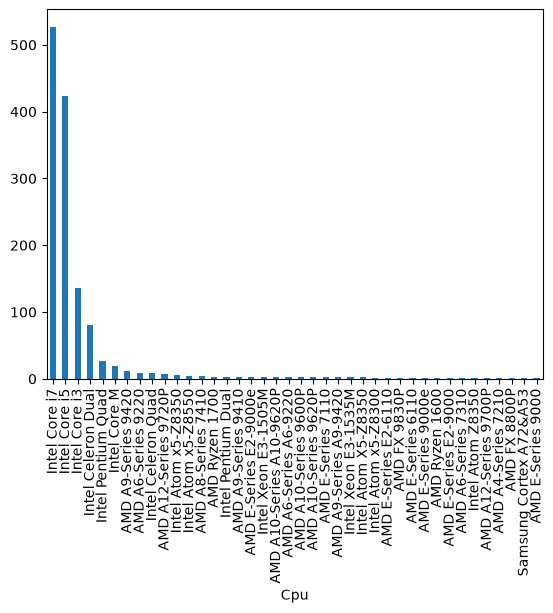

In [168]:
df['Cpu'].value_counts().plot(kind = 'bar')

In [169]:
df['Cpu'].value_counts()

Cpu
Intel Core i7               527
Intel Core i5               423
Intel Core i3               136
Intel Celeron Dual           80
Intel Pentium Quad           27
Intel Core M                 19
AMD A9-Series 9420           12
AMD A6-Series 9220            8
Intel Celeron Quad            8
AMD A12-Series 9720P          7
Intel Atom x5-Z8350           5
Intel Atom x5-Z8550           4
AMD A8-Series 7410            4
AMD Ryzen 1700                3
Intel Pentium Dual            3
AMD A9-Series 9410            3
AMD E-Series E2-9000e         2
Intel Xeon E3-1505M           2
AMD A10-Series A10-9620P      2
AMD A6-Series A6-9220         2
AMD A10-Series 9600P          2
AMD A10-Series 9620P          2
AMD E-Series 7110             2
AMD A9-Series A9-9420         2
Intel Xeon E3-1535M           2
Intel Atom X5-Z8350           2
Intel Atom x5-Z8300           1
AMD E-Series E2-6110          1
AMD FX 9830P                  1
AMD E-Series 6110             1
AMD E-Series 9000e            1
AMD 

In [170]:
def fit_cpu(text):
    if text == 'Intel Core i7' or text == 'Intel Core i5' or text == 'Intel Core i3':
        return text
    elif text.split()[0] == 'Intel':
        return 'Other Intel Processor'
    elif text[4] == 'A':
        return 'AMD-A-Series'
    elif text[4] == 'D':
        return 'AMD-D-Series'
    elif text[4] == 'E':
        return 'AMD-E-Series'
    elif text[4] == 'F':
        return 'AMD-F-Series'
    else:
        return 'AMD-Rysen-Series'

In [171]:
fit_cpu('AMD E-Series 7110')


'AMD-E-Series'

In [172]:
df['Cpu']=df['Cpu'].apply(fit_cpu)

<Axes: xlabel='Cpu'>

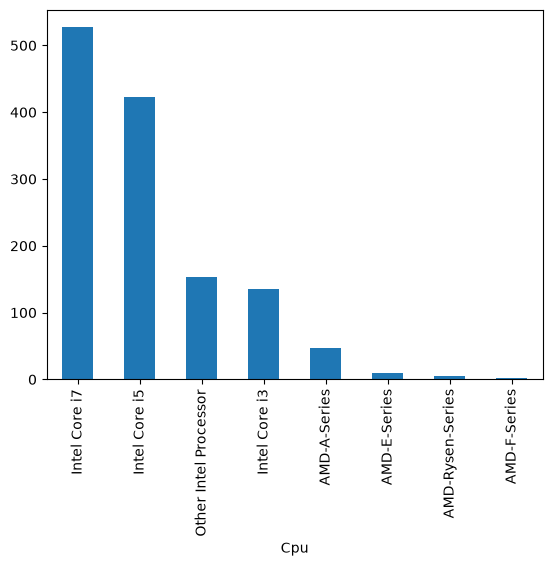

In [173]:
df['Cpu'].value_counts().plot(kind = 'bar')

In [174]:
df.head() 

,Company,TypeName,Inches,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,X_Res,Y_Res,TouchScreen,IPS
0,Apple,Ultrabook,13.3,Intel Core i5,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,148093.4,2560,1600,0,1
1,Apple,Ultrabook,13.3,Intel Core i5,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,99318.8,1440,900,0,0
2,HP,Notebook,15.6,Intel Core i5,8,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,63595.0,1920,1080,0,0
3,Apple,Ultrabook,15.4,Intel Core i7,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,280592.2,2880,1800,0,1
4,Apple,Ultrabook,13.3,Intel Core i5,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,199411.8,2560,1600,0,1


In [175]:
# Step 12: Drop the 'Memory' Column (Too Inconsistent to Parse Simply)
df.drop('Memory', axis = 1 , inplace = True)

In [176]:
df.head()

,Company,TypeName,Inches,Cpu,Ram,Gpu,OpSys,Weight,Price,X_Res,Y_Res,TouchScreen,IPS
0,Apple,Ultrabook,13.3,Intel Core i5,8,Intel Iris Plus Graphics 640,macOS,1.37kg,148093.4,2560,1600,0,1
1,Apple,Ultrabook,13.3,Intel Core i5,8,Intel HD Graphics 6000,macOS,1.34kg,99318.8,1440,900,0,0
2,HP,Notebook,15.6,Intel Core i5,8,Intel HD Graphics 620,No OS,1.86kg,63595.0,1920,1080,0,0
3,Apple,Ultrabook,15.4,Intel Core i7,16,AMD Radeon Pro 455,macOS,1.83kg,280592.2,2880,1800,0,1
4,Apple,Ultrabook,13.3,Intel Core i5,8,Intel Iris Plus Graphics 650,macOS,1.37kg,199411.8,2560,1600,0,1


In [177]:
# Step 13: Feature Extraction — 'Gpu'
df['Gpu'] = df['Gpu'].apply(lambda x : ' '.join(x.split()[:2]))

In [178]:
df.head()

,Company,TypeName,Inches,Cpu,Ram,Gpu,OpSys,Weight,Price,X_Res,Y_Res,TouchScreen,IPS
0,Apple,Ultrabook,13.3,Intel Core i5,8,Intel Iris,macOS,1.37kg,148093.4,2560,1600,0,1
1,Apple,Ultrabook,13.3,Intel Core i5,8,Intel HD,macOS,1.34kg,99318.8,1440,900,0,0
2,HP,Notebook,15.6,Intel Core i5,8,Intel HD,No OS,1.86kg,63595.0,1920,1080,0,0
3,Apple,Ultrabook,15.4,Intel Core i7,16,AMD Radeon,macOS,1.83kg,280592.2,2880,1800,0,1
4,Apple,Ultrabook,13.3,Intel Core i5,8,Intel Iris,macOS,1.37kg,199411.8,2560,1600,0,1


In [179]:
#   Step 14: Categorize the 'OpSys' Column

<Axes: xlabel='OpSys'>

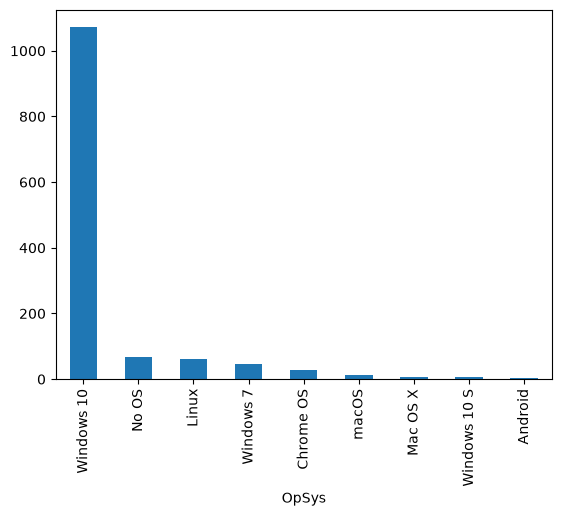

In [180]:
df['OpSys'].value_counts().plot(kind = 'bar')

In [181]:
df['OpSys'].value_counts()

OpSys
Windows 10      1072
No OS             66
Linux             62
Windows 7         45
Chrome OS         27
macOS             13
Mac OS X           8
Windows 10 S       8
Android            2
Name: count, dtype: int64

In [182]:
def sys_os(text):
    if text == 'Windows 10' or text == 'Windows 10 S':
        return 'Windows 10'
    elif text == 'Mac OS X' or text == 'macOS':
        return ' Mac OS'
    elif text == 'Windows 7':
        return text
    elif text == 'No OS':
        return 'No OS'
    else :
        return 'Other Os_system'


In [183]:
df['OpSys']=df['OpSys'].apply(sys_os)

<Axes: xlabel='OpSys'>

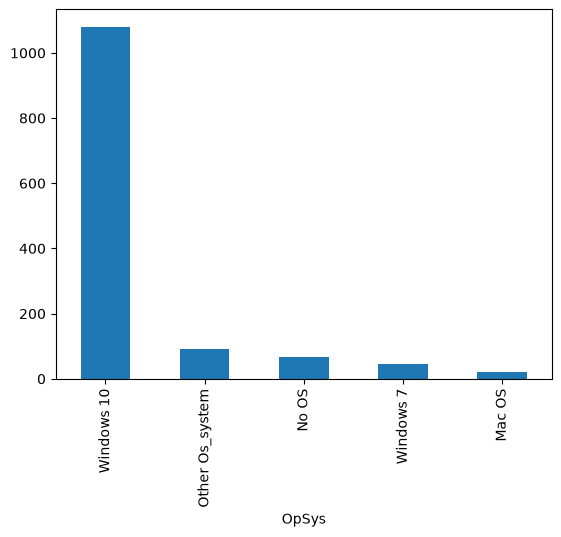

In [184]:
df['OpSys'].value_counts().plot(kind = 'bar')

In [185]:
df.head()

,Company,TypeName,Inches,Cpu,Ram,Gpu,OpSys,Weight,Price,X_Res,Y_Res,TouchScreen,IPS
0,Apple,Ultrabook,13.3,Intel Core i5,8,Intel Iris,Mac OS,1.37kg,148093.4,2560,1600,0,1
1,Apple,Ultrabook,13.3,Intel Core i5,8,Intel HD,Mac OS,1.34kg,99318.8,1440,900,0,0
2,HP,Notebook,15.6,Intel Core i5,8,Intel HD,No OS,1.86kg,63595.0,1920,1080,0,0
3,Apple,Ultrabook,15.4,Intel Core i7,16,AMD Radeon,Mac OS,1.83kg,280592.2,2880,1800,0,1
4,Apple,Ultrabook,13.3,Intel Core i5,8,Intel Iris,Mac OS,1.37kg,199411.8,2560,1600,0,1


In [186]:
#   Step 15: Clean the 'Weight' Column

In [187]:
df['Weight'] = df['Weight'].apply(lambda a: a.replace('kg',''))

In [188]:
df.head()

,Company,TypeName,Inches,Cpu,Ram,Gpu,OpSys,Weight,Price,X_Res,Y_Res,TouchScreen,IPS
0,Apple,Ultrabook,13.3,Intel Core i5,8,Intel Iris,Mac OS,1.37,148093.4,2560,1600,0,1
1,Apple,Ultrabook,13.3,Intel Core i5,8,Intel HD,Mac OS,1.34,99318.8,1440,900,0,0
2,HP,Notebook,15.6,Intel Core i5,8,Intel HD,No OS,1.86,63595.0,1920,1080,0,0
3,Apple,Ultrabook,15.4,Intel Core i7,16,AMD Radeon,Mac OS,1.83,280592.2,2880,1800,0,1
4,Apple,Ultrabook,13.3,Intel Core i5,8,Intel Iris,Mac OS,1.37,199411.8,2560,1600,0,1


In [189]:
df['X_Res'] = df['X_Res'].astype(int)
df['Y_Res'] = df['Y_Res'].astype(int)

In [190]:
# Step 16: Engineer a New Feature — PPI (Pixels Per Inch)
df['ppi'] = round(((df['X_Res']**2) + (df['Y_Res']**2))**0.5 / df['Inches'],0)

In [191]:
df['ppi'] = df['ppi'].astype(int)

In [192]:
df.drop('X_Res' , axis = 1 , inplace = True)

In [193]:
df.drop('Y_Res' , axis = 1 , inplace = True)

In [194]:
df.drop('Inches' , axis = 1 , inplace = True)

In [195]:
df['Price'] = df['Price'].astype(int)

In [196]:
df

,Company,TypeName,Cpu,Ram,Gpu,OpSys,Weight,Price,TouchScreen,IPS,ppi
0,Apple,Ultrabook,Intel Core i5,8,Intel Iris,Mac OS,1.37,148093,0,1,227
1,Apple,Ultrabook,Intel Core i5,8,Intel HD,Mac OS,1.34,99318,0,0,128
2,HP,Notebook,Intel Core i5,8,Intel HD,No OS,1.86,63595,0,0,141
3,Apple,Ultrabook,Intel Core i7,16,AMD Radeon,Mac OS,1.83,280592,0,1,221
4,Apple,Ultrabook,Intel Core i5,8,Intel Iris,Mac OS,1.37,199411,0,1,227
...,...,...,...,...,...,...,...,...,...,...,...
1298,Lenovo,2 in 1 Convertible,Intel Core i7,4,Intel HD,Windows 10,1.8,70562,1,1,157
1299,Lenovo,2 in 1 Convertible,Intel Core i7,16,Intel HD,Windows 10,1.3,165789,1,1,276
1300,Lenovo,Notebook,Other Intel Processor,2,Intel HD,Windows 10,1.5,25327,0,0,112
1301,HP,Notebook,Intel Core i7,6,AMD Radeon,Windows 10,2.19,84498,0,0,100


In [197]:
df.to_csv("Cleaned_Data.csv")